In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("susant4learning/holiday-package-purchase-prediction")

print("Path to dataset files:", path)

100%|██████████| 79.6k/79.6k [00:00<00:00, 23.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/susant4learning/holiday-package-purchase-prediction/versions/1


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/susant4learning/holiday-package-purchase-prediction/versions/1/Travel.csv')

In [ ]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [ ]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [ ]:
df['NumberOfChildrenVisiting']=df['NumberOfChildrenVisiting'].fillna(0.0)

In [ ]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [ ]:
df['DurationOfPitch'].value_counts()

,count
DurationOfPitch,
9.0,483
7.0,342
8.0,333
6.0,307
16.0,274
15.0,269
14.0,253
10.0,244
13.0,223


In [ ]:
df['NumberOfTrips'].value_counts()

,count
NumberOfTrips,
2.0,1464
3.0,1079
1.0,620
4.0,478
5.0,458
6.0,322
7.0,218
8.0,105
19.0,1


In [ ]:
for col in df.columns:
  if(df[col].dtype == 'object'):
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].median())

In [ ]:
df.drop(columns=['CustomerID'])

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [ ]:
df['NumberOfPeopleVisiting']=df['NumberOfChildrenVisiting']+df['NumberOfPersonVisiting']

In [ ]:
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],inplace=True)

In [ ]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberOfPeopleVisiting
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [ ]:
df.drop(columns='CustomerID',inplace=True)

In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberOfPeopleVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   object 
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   object 
 6   Gender                  4888 non-null   object 
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   object 
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   object 
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [ ]:
df['Gender']=df['Gender'].replace('Fe Male','Female')

In [ ]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [ ]:
cat_features=[features for features in df.columns if df[features].dtype=='object']
print('Number of categorical features: ',len(cat_features))


Number of categorical features:  6


In [ ]:
num_features=[features for features in df.columns if df[features].dtype!='object' and features != 'ProdTaken']
print('Number of numerical features: ',len(num_features))


Number of numerical features:  11


In [ ]:
dis_features=[features for features in num_features if len(df[features].unique())<=12]
print('Number of discrete features: ',len(dis_features))

Number of discrete features:  8


In [ ]:
cont_features=[features for features in num_features if len(df[features].unique())>12]
print('Number of continuous features: ',len(cont_features))

Number of continuous features:  3


In [ ]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched',
       'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome',
       'NumberOfPeopleVisiting'],
      dtype='object')

In [ ]:
X=df.drop(columns='ProdTaken')
y=df['ProdTaken']

In [ ]:
X

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberOfPeopleVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
numerical_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

In [ ]:
preprocessor=ColumnTransformer([
    ('OneHotEncoder',oh_transformer,cat_features),
    ('StandardScaler',numerical_transformer,num_features)
])

In [ ]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [ ]:
X_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.27969734,
        -0.73033753, -0.76493678],
       [ 1.        ,  0.        ,  0.        , ..., -1.27969734,
        -0.66394968, -0.05748917],
       [ 1.        ,  0.        ,  0.        , ...,  0.78143477,
        -0.417017  , -0.76493678],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78143477,
        -0.08075222, -0.05748917],
       [ 1.        ,  0.        ,  1.        , ...,  0.78143477,
         1.97576639, -0.05748917],
       [ 1.        ,  0.        ,  1.        , ..., -1.27969734,
         1.28837951, -1.47238439]])

In [ ]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,auc
models={
    'RandomForestClassifier':RandomForestClassifier(),
    'AdaboostClassifier': AdaBoostClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'LogisticRegression':LogisticRegression()
}

for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,y_train)
  print(list(models.keys())[i])
  print('Results for Training data')
  print('Accuracy:',accuracy_score(y_train,model.predict(X_train)))
  print('Precision:',precision_score(y_train,model.predict(X_train)))
  print('Recall:',recall_score(y_train,model.predict(X_train)))
  print('Accuracy:',accuracy_score(y_train,model.predict(X_train)))
  print('\n')
  print('Results for Test data')
  print('Accuracy:',accuracy_score(y_test,model.predict(X_test)))
  print('Precision:',precision_score(y_test,model.predict(X_test)))
  print('Recall:',recall_score(y_test,model.predict(X_test)))
  print('Accuracy:',accuracy_score(y_test,model.predict(X_test)))
  print('------------------------------------------------------')

RandomForestClassifier
Results for Training data
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Accuracy: 1.0


Results for Test data
Accuracy: 0.9202453987730062
Precision: 0.9385474860335196
Recall: 0.6131386861313869
Accuracy: 0.9202453987730062
------------------------------------------------------
AdaboostClassifier
Results for Training data
Accuracy: 0.8433206664717918
Precision: 0.7696078431372549
Recall: 0.24303405572755418
Accuracy: 0.8433206664717918


Results for Test data
Accuracy: 0.8316291751874574
Precision: 0.6483516483516484
Recall: 0.21532846715328466
Accuracy: 0.8316291751874574
------------------------------------------------------
DecisionTreeClassifier
Results for Training data
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Accuracy: 1.0


Results for Test data
Accuracy: 0.9066121336059987
Precision: 0.7420494699646644
Recall: 0.7664233576642335
Accuracy: 0.9066121336059987
------------------------------------------------------
LogisticRegression
Results for Training data
Acc

In [ ]:
params={
    'n_estimators':[5,10,100,1000],
    'max_depth':[1,2,3,4,5,6,7,8,9],
    'min_samples_split':[2,4,8,10,20],
    'max_features':['sqrt', 'log2']
}
ada_params={
    'n_estimators':[50,60,70,80],
    'learning_rate':[0.001,0.01,0.1,1]
}

In [ ]:
ada_params

{'n_estimators': [50, 60, 70, 80], 'learning_rate': [0.001, 0.01, 0.1, 1]}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
randomcv_model=[
    ('RF',RandomForestClassifier(),params),
    ('ADA',AdaBoostClassifier(),ada_params)
]



In [ ]:
randomcv_model

[('RF',
  RandomForestClassifier(),
  {'n_estimators': [5, 10, 100, 1000],
   'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
   'min_samples_split': [2, 4, 8, 10, 20],
   'max_features': ['sqrt', 'log2']}),
 ('ADA',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 80], 'learning_rate': [0.001, 0.01, 0.1, 1]})]

In [ ]:
model_param={}
for name,model,param in randomcv_model:
  randomcv=RandomizedSearchCV(estimator=model,param_distributions=param,cv=5,n_iter=100,verbose=2,n_jobs=-1)
  randomcv.fit(X_train,y_train)
  model_param[name]=randomcv.best_params_

for model_name in model_param:
  print('Best params for',model_name)
  print(model_param[model_name])


Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=100. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for RF
{'n_estimators': 100, 'min_samples_split': 8, 'max_features': 'sqrt', 'max_depth': 9}
Best params for ADA
{'n_estimators': 70, 'learning_rate': 1}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
models={
    "RandomForestClassifier":RandomForestClassifier(n_estimators=100, min_samples_split=8, max_features='sqrt', max_depth=9),
    "AdaBoostClassifier":AdaBoostClassifier(n_estimators=70, learning_rate=1)
}
for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,y_train)

  print(list(models.keys())[i])
  print('Results for Training data')
  print('Accuracy:',accuracy_score(y_train,model.predict(X_train)))
  print('Precision:',precision_score(y_train,model.predict(X_train)))
  print('Recall:',recall_score(y_train,model.predict(X_train)))
  print('Accuracy:',accuracy_score(y_train,model.predict(X_train)))
  print('Roc_Auc_Score:',roc_auc_score(y_train,model.predict(X_train)))
  print('\n')
  print('Results for Test data')
  print('Accuracy:',accuracy_score(y_test,model.predict(X_test)))
  print('Precision:',precision_score(y_test,model.predict(X_test)))
  print('Recall:',recall_score(y_test,model.predict(X_test)))
  print('Accuracy:',accuracy_score(y_test,model.predict(X_test)))
  print('Roc_Auc_Score:',roc_auc_score(y_test,model.predict(X_test)))
  print('------------------------------------------------------')

RandomForestClassifier
Results for Training data
Accuracy: 0.912890967553347
Precision: 0.978021978021978
Recall: 0.5510835913312694
Accuracy: 0.912890967553347
Roc_Auc_Score: 0.7741003542241933


Results for Test data
Accuracy: 0.8657123381049762
Precision: 0.8407079646017699
Recall: 0.3467153284671533
Accuracy: 0.8657123381049762
Roc_Auc_Score: 0.665813657527793
------------------------------------------------------
AdaBoostClassifier
Results for Training data
Accuracy: 0.8471207249342297
Precision: 0.786046511627907
Recall: 0.26160990712074306
Accuracy: 0.8471207249342297
Roc_Auc_Score: 0.6225166652720832


Results for Test data
Accuracy: 0.8377641445126107
Precision: 0.6914893617021277
Recall: 0.23722627737226276
Accuracy: 0.8377641445126107
Roc_Auc_Score: 0.6064589056601464
------------------------------------------------------


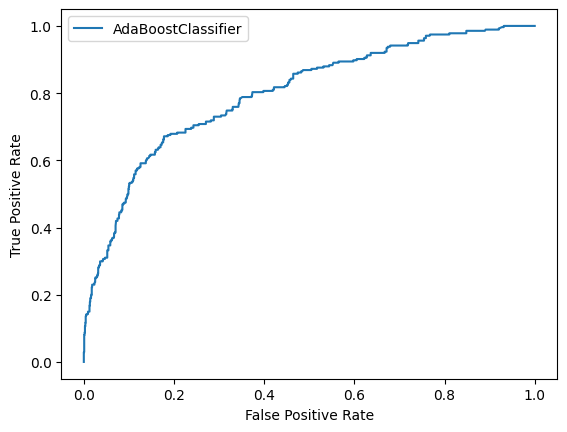

In [ ]:
from sklearn.metrics import roc_curve
auc_models=[{
    'label':'AdaBoostClassifier',
    'model': AdaBoostClassifier(n_estimators=70, learning_rate=1),
}]
for algo in auc_models:
  model=algo['model']
  model.fit(X_train,y_train)

  fpr,tpr,threshold=roc_curve(y_test,model.predict_proba(X_test)[:,1])
  import matplotlib.pyplot as plt
  plt.plot(fpr,tpr,label=algo['label'])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend()
  plt.show()


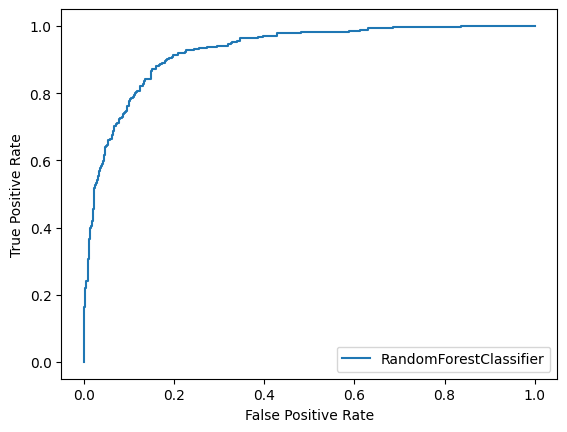

In [ ]:
from sklearn.metrics import roc_curve
auc_models=[{
    'label':'RandomForestClassifier',
    'model': RandomForestClassifier(n_estimators=100, min_samples_split=8, max_features='sqrt', max_depth=9),
}]
for algo in auc_models:
  model=algo['model']
  model.fit(X_train,y_train)

  fpr,tpr,threshold=roc_curve(y_test,model.predict_proba(X_test)[:,1])
  import matplotlib.pyplot as plt
  plt.plot(fpr,tpr,label=algo['label'])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend()
  plt.show()
